**Laboratorio 1: Estimación de µ y σ para GBM**

  LABORATORIO 1: Estimación de GBM con datos reales

Activo: AAPL  |  Periodo: 2021-01-01 → 2024-01-01
Observaciones: 753

Parámetros estimados (anualizados):
  µ  (drift)      = 0.1776  (17.76%)
  σ  (volatilidad)= 0.2777  (27.77%)


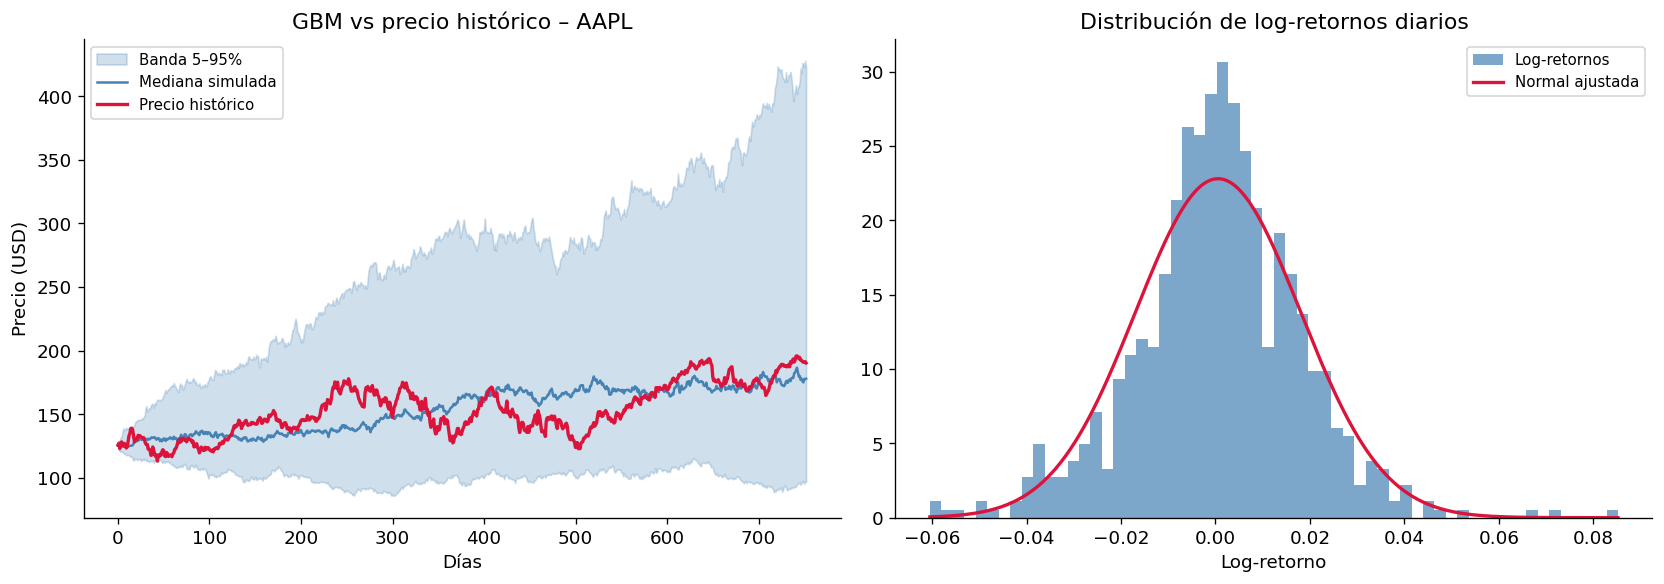


Tabla resumen:
   Parámetro    Valor
µ anualizado   0.1776
σ anualizado   0.2777
    m diario 0.000552
    s diario 0.017494

Discusión: El GBM captura la tendencia y el orden de magnitud de la
volatilidad, pero no las colas gruesas ni el clustering observados.


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

# Configuración general de gráficas
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ============================================================
#  LABORATORIO 1
#  Estimación de un Movimiento Browniano Geométrico (GBM)
#  con datos reales de una acción
# ============================================================

print("=" * 60)
print("  LABORATORIO 1: Estimación de GBM con datos reales")
print("=" * 60)

# ── Parámetros configurables ─────────────────────────────────
TICKER_L1   = "AAPL"          # Cambia por MSFT o SPY si prefieres
INICIO_L1   = "2021-01-01"
FIN_L1      = "2024-01-01"
N_TRAY_L1   = 50              # Número de trayectorias simuladas
SEED_L1     = 42

# ── Paso 1: Descarga de precios ajustados ────────────────────
datos_l1 = yf.download(TICKER_L1, start=INICIO_L1, end=FIN_L1,
                       auto_adjust=True, progress=False)["Close"]
datos_l1 = datos_l1.dropna()
print(f"\nActivo: {TICKER_L1}  |  Periodo: {INICIO_L1} → {FIN_L1}")
print(f"Observaciones: {len(datos_l1)}")

# ── Paso 2: Log-retornos diarios ─────────────────────────────
log_ret_l1 = np.log(datos_l1 / datos_l1.shift(1)).dropna()

# ── Paso 3 & 4: Estimación y anualización ────────────────────
m_hat = log_ret_l1.mean()       # media muestral diaria
s_hat = log_ret_l1.std()        # desv. estándar muestral diaria

mu_hat    = float(252 * m_hat + 0.5 * (252 * s_hat**2))
sigma_hat = float(np.sqrt(252) * s_hat)

print(f"\nParámetros estimados (anualizados):")
print(f"  µ  (drift)      = {mu_hat:.4f}  ({mu_hat*100:.2f}%)")
print(f"  σ  (volatilidad)= {sigma_hat:.4f}  ({sigma_hat*100:.2f}%)")

# ── Paso 5: Simulación de trayectorias GBM ──────────────────
np.random.seed(SEED_L1)
T_dias  = len(datos_l1)
dt      = 1 / 252
S0      = float(datos_l1.iloc[0])

# Matriz de trayectorias (T_dias × N_TRAY_L1)
Z = np.random.standard_normal((T_dias - 1, N_TRAY_L1))
incrementos = (mu_hat - 0.5 * sigma_hat**2) * dt + sigma_hat * np.sqrt(dt) * Z
log_S  = np.vstack([np.zeros((1, N_TRAY_L1)),
                    np.cumsum(incrementos, axis=0)])
tray   = S0 * np.exp(log_S)

# Bandas percentílicas
p5  = np.percentile(tray, 5,  axis=1)
p50 = np.percentile(tray, 50, axis=1)
p95 = np.percentile(tray, 95, axis=1)

# ── Paso 6: Comparación visual ───────────────────────────────
fechas = datos_l1.index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica izquierda: trayectorias simuladas + banda
ax = axes[0]
ax.fill_between(range(T_dias), p5, p95, alpha=0.25,
                color="steelblue", label="Banda 5–95%")
ax.plot(p50, color="steelblue", lw=1.5, label="Mediana simulada")
ax.plot(datos_l1.values, color="crimson", lw=2, label="Precio histórico")
ax.set_title(f"GBM vs precio histórico – {TICKER_L1}")
ax.set_xlabel("Días")
ax.set_ylabel("Precio (USD)")
ax.legend(fontsize=9)

# Gráfica derecha: distribución de log-retornos
ax2 = axes[1]
ax2.hist(log_ret_l1, bins=60, density=True,
         color="steelblue", alpha=0.7, label="Log-retornos")
x_grid = np.linspace(log_ret_l1.min(), log_ret_l1.max(), 300)
ax2.plot(x_grid,
         norm.pdf(x_grid, m_hat.iloc[0], s_hat.iloc[0]),
         color="crimson", lw=2, label="Normal ajustada")
ax2.set_title("Distribución de log-retornos diarios")
ax2.set_xlabel("Log-retorno")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("lab1_gbm.png", bbox_inches="tight")
plt.show()

print("\nTabla resumen:")
tabla_l1 = pd.DataFrame({
    "Parámetro": ["µ anualizado", "σ anualizado", "m diario", "s diario"],
    "Valor":     [f"{mu_hat:.4f}", f"{sigma_hat:.4f}",
                  f"{m_hat.iloc[0]:.6f}", f"{s_hat.iloc[0]:.6f}"]
})
print(tabla_l1.to_string(index=False))
print("\nDiscusión: El GBM captura la tendencia y el orden de magnitud de la")
print("volatilidad, pero no las colas gruesas ni el clustering observados.")

**Laboratorio 2: Volatilidad realizada y ventanas móviles**


  LABORATORIO 2: Volatilidad realizada y ventanas móviles

Activo: SPY  |  Periodo: 2018-01-01 → 2024-01-01
Observaciones: 1509


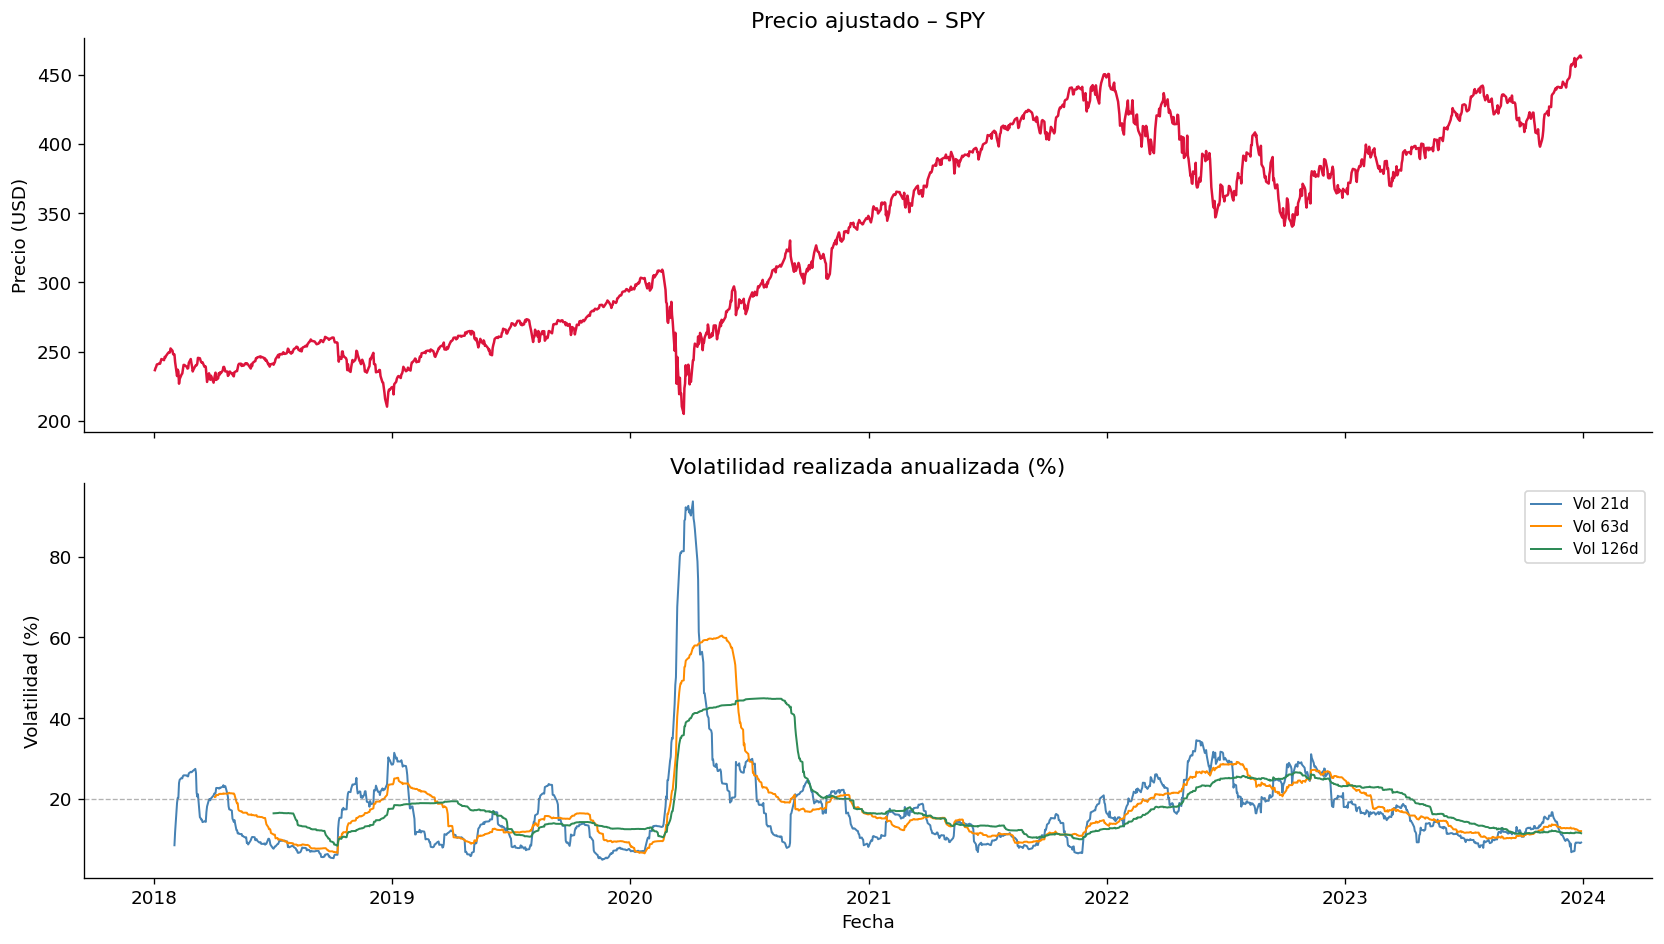


Estadísticos de volatilidad anualizada (%):
       Vol 21d  Vol 63d  Vol 126d
count  1488.00  1446.00   1383.00
mean     17.24    18.08     18.94
std      11.38    10.12      8.84
min       4.99     6.57      8.48
25%      10.34    11.66     12.78
50%      14.71    15.37     16.41
75%      21.19    21.34     22.33
max      93.67    60.44     44.96

Observación: Se aprecia clustering — periodos de alta volatilidad
(ej. COVID-19, 2022) se agrupan, consistente con modelos GARCH/SV.


In [14]:
print("\n" + "=" * 60)
print("  LABORATORIO 2: Volatilidad realizada y ventanas móviles")
print("=" * 60)

# ── Parámetros configurables ─────────────────────────────────
TICKER_L2  = "SPY"
INICIO_L2  = "2018-01-01"
FIN_L2     = "2024-01-01"
VENTANAS   = [21, 63, 126]      # días: ≈ 1 mes, 3 meses, 6 meses

# ── Descarga y log-retornos ──────────────────────────────────
datos_l2   = yf.download(TICKER_L2, start=INICIO_L2, end=FIN_L2,
                          auto_adjust=True, progress=False)["Close"].dropna()
log_ret_l2 = np.log(datos_l2 / datos_l2.shift(1)).dropna()

print(f"\nActivo: {TICKER_L2}  |  Periodo: {INICIO_L2} → {FIN_L2}")
print(f"Observaciones: {len(datos_l2)}")

# ── Cálculo de volatilidad rodante anualizada ────────────────
vol_series = {}
for w in VENTANAS:
    vol_series[f"Vol {w}d"] = log_ret_l2.rolling(w).std().squeeze() * np.sqrt(252)

vol_df = pd.DataFrame(vol_series).dropna(how="all")

# ── Gráfica ──────────────────────────────────────────────────
colores = ["steelblue", "darkorange", "seagreen"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: precio
ax1.plot(datos_l2.index, datos_l2.values, color="crimson", lw=1.5)
ax1.set_title(f"Precio ajustado – {TICKER_L2}")
ax1.set_ylabel("Precio (USD)")

# Panel inferior: volatilidad rodante
for col, c in zip(vol_df.columns, colores):
    ax2.plot(vol_df.index, vol_df[col] * 100, label=col, lw=1.2, color=c)
ax2.set_title("Volatilidad realizada anualizada (%)")
ax2.set_ylabel("Volatilidad (%)")
ax2.set_xlabel("Fecha")
ax2.legend(fontsize=9)
ax2.axhline(y=20, ls="--", lw=0.8, color="gray", alpha=0.6,
            label="Referencia 20%")

plt.tight_layout()
plt.savefig("lab2_volatilidad.png", bbox_inches="tight")
plt.show()

# Estadísticos resumen
print("\nEstadísticos de volatilidad anualizada (%):")
print((vol_df * 100).describe().round(2).to_string())
print("\nObservación: Se aprecia clustering — periodos de alta volatilidad")
print("(ej. COVID-19, 2022) se agrupan, consistente con modelos GARCH/SV.")

**Laboratorio 3: Valuación Monte Carlo de opción europea**


  LABORATORIO 3: Valuación Monte Carlo – Opción Europea

Activo: SPY  |  S0 = 462.58  |  K = 450.0
σ histórica = 0.1761  |  r = 0.05  |  T = 1.0 año
Tipo: CALL  |  Simulaciones: 100,000

Resultados:
  Precio Monte Carlo     : 51.4334
  Error estándar MC      : 0.2008
  IC 95%                 : [51.0399, 51.8270]
  Precio Black-Scholes   : 51.4777
  Diferencia BS – MC     : 0.0442


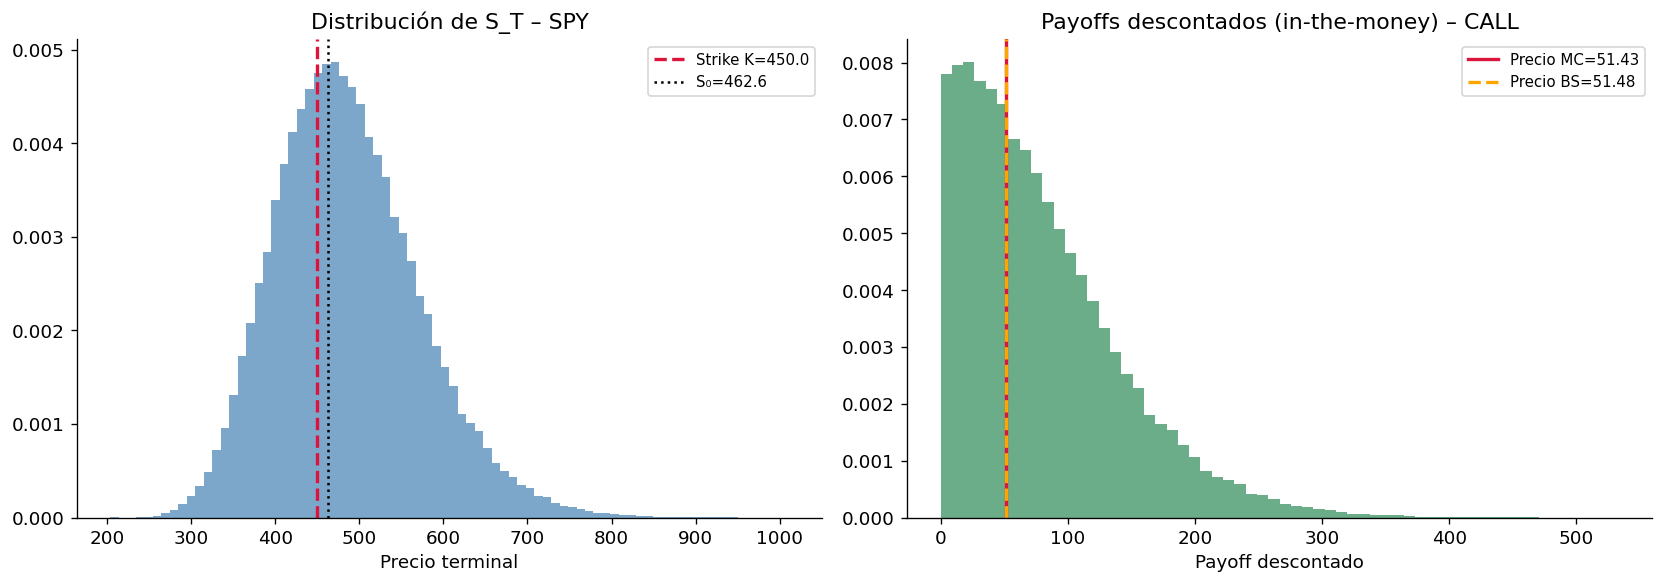

In [15]:
print("\n" + "=" * 60)
print("  LABORATORIO 3: Valuación Monte Carlo – Opción Europea")
print("=" * 60)

# ── Parámetros configurables ─────────────────────────────────
TICKER_L3  = "SPY"
INICIO_L3  = "2021-01-01"
FIN_L3     = "2024-01-01"
K          = 450.0       # Strike (ajusta al nivel actual de SPY)
T          = 1.0         # Vencimiento en años
r          = 0.05        # Tasa libre de riesgo anualizada
N_SIM      = 100_000     # Trayectorias Monte Carlo
TIPO       = "call"      # "call" o "put"
SEED_L3    = 0

# ── Calibración de σ con datos históricos ───────────────────
datos_l3   = yf.download(TICKER_L3, start=INICIO_L3, end=FIN_L3,
                          auto_adjust=True, progress=False)["Close"].dropna()
log_ret_l3 = np.log(datos_l3 / datos_l3.shift(1)).dropna()
sigma_l3   = (log_ret_l3.std() * np.sqrt(252)).iloc[0]
S0_l3      = float(datos_l3.iloc[-1])

print(f"\nActivo: {TICKER_L3}  |  S0 = {S0_l3:.2f}  |  K = {K}")
print(f"σ histórica = {sigma_l3:.4f}  |  r = {r}  |  T = {T} año")
print(f"Tipo: {TIPO.upper()}  |  Simulaciones: {N_SIM:,}")

# ── Paso 3: Simulación neutral al riesgo ─────────────────────
np.random.seed(SEED_L3)
Z_l3 = np.random.standard_normal(N_SIM)
ST   = S0_l3 * np.exp((r - 0.5 * sigma_l3**2) * T + sigma_l3 * np.sqrt(T) * Z_l3)

# ── Paso 4 & 5: Payoff y descuento ───────────────────────────
if TIPO == "call":
    payoffs = np.maximum(ST - K, 0)
else:
    payoffs = np.maximum(K - ST, 0)

precio_mc = np.exp(-r * T) * payoffs.mean()
error_mc  = np.exp(-r * T) * payoffs.std() / np.sqrt(N_SIM)
ic_inf    = precio_mc - 1.96 * error_mc
ic_sup    = precio_mc + 1.96 * error_mc

# ── Black-Scholes analítico (referencia) ─────────────────────
def bs_precio(S, K, T, r, sigma, tipo="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if tipo == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

precio_bs = bs_precio(S0_l3, K, T, r, sigma_l3, TIPO)

print(f"\nResultados:")
print(f"  Precio Monte Carlo     : {precio_mc:.4f}")
print(f"  Error estándar MC      : {error_mc:.4f}")
print(f"  IC 95%                 : [{ic_inf:.4f}, {ic_sup:.4f}]")
print(f"  Precio Black-Scholes   : {precio_bs:.4f}")
print(f"  Diferencia BS – MC     : {abs(precio_bs - precio_mc):.4f}")

# ── Gráfica ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de ST
ax = axes[0]
ax.hist(ST, bins=80, density=True, color="steelblue", alpha=0.7)
ax.axvline(K, color="crimson", lw=2, ls="--", label=f"Strike K={K}")
ax.axvline(S0_l3, color="black", lw=1.5, ls=":", label=f"S₀={S0_l3:.1f}")
ax.set_title(f"Distribución de S_T – {TICKER_L3}")
ax.set_xlabel("Precio terminal")
ax.legend(fontsize=9)

# Distribución de payoffs descontados
ax2 = axes[1]
payoffs_desc = np.exp(-r * T) * payoffs
ax2.hist(payoffs_desc[payoffs_desc > 0], bins=60,
         density=True, color="seagreen", alpha=0.7)
ax2.axvline(precio_mc, color="crimson", lw=2, label=f"Precio MC={precio_mc:.2f}")
ax2.axvline(precio_bs, color="orange", lw=2, ls="--",
            label=f"Precio BS={precio_bs:.2f}")
ax2.set_title(f"Payoffs descontados (in-the-money) – {TIPO.upper()}")
ax2.set_xlabel("Payoff descontado")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("lab3_montecarlo.png", bbox_inches="tight")
plt.show()

**Laboratorio 4: Opción americana con Longstaff–
Schwartz**


  LABORATORIO 4: Opción Americana – Longstaff-Schwartz

Activo: SPY  |  S0 = 462.58  |  K = 450.0
σ = 0.1761  |  r = 0.05  |  T = 1.0
Simulaciones: 50,000  |  Pasos: 252

Resultados:
  Precio PUT Americana (LSM) : 18.5299  ± 0.1147
  Precio PUT Europea  (BS)   : 16.9509
  Prima ejercicio temprano   : 1.5790


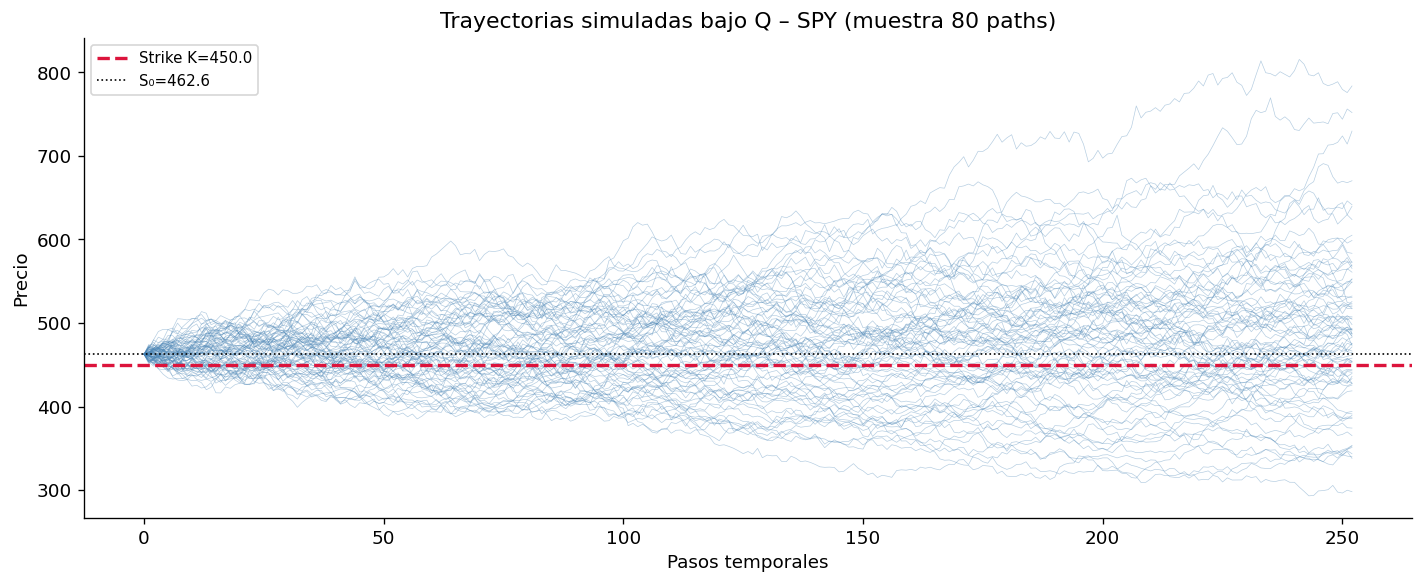

In [16]:
print("\n" + "=" * 60)
print("  LABORATORIO 4: Opción Americana – Longstaff-Schwartz")
print("=" * 60)

# ── Parámetros configurables ─────────────────────────────────
TICKER_L4  = "SPY"
INICIO_L4  = "2021-01-01"
FIN_L4     = "2024-01-01"
K_L4       = 450.0
T_L4       = 1.0
r_L4       = 0.05
N_SIM_L4   = 50_000
N_PASOS_L4 = 252          # pasos diarios
SEED_L4    = 7

# ── Calibración ─────────────────────────────────────────────
datos_l4   = yf.download(TICKER_L4, start=INICIO_L4, end=FIN_L4,
                          auto_adjust=True, progress=False)["Close"].dropna()
log_ret_l4 = np.log(datos_l4 / datos_l4.shift(1)).dropna()
sigma_l4   = (log_ret_l4.std() * np.sqrt(252)).iloc[0]
S0_l4      = float(datos_l4.iloc[-1])

print(f"\nActivo: {TICKER_L4}  |  S0 = {S0_l4:.2f}  |  K = {K_L4}")
print(f"σ = {sigma_l4:.4f}  |  r = {r_L4}  |  T = {T_L4}")
print(f"Simulaciones: {N_SIM_L4:,}  |  Pasos: {N_PASOS_L4}")

# ── Simulación de trayectorias bajo Q ────────────────────────
np.random.seed(SEED_L4)
dt_l4   = T_L4 / N_PASOS_L4
factor  = np.exp((r_L4 - 0.5 * sigma_l4**2) * dt_l4)
difus   = sigma_l4 * np.sqrt(dt_l4)

# Trayectorias con antithetic variates para reducir varianza
Z_raw   = np.random.standard_normal((N_PASOS_L4, N_SIM_L4 // 2))
Z_all   = np.concatenate([Z_raw, -Z_raw], axis=1)

S_tray  = np.zeros((N_PASOS_L4 + 1, N_SIM_L4))
S_tray[0] = S0_l4
for t in range(1, N_PASOS_L4 + 1):
    S_tray[t] = S_tray[t - 1] * factor * np.exp(difus * Z_all[t - 1])

# ── Algoritmo Longstaff-Schwartz (regresión hacia atrás) ─────
df_l4   = np.exp(-r_L4 * dt_l4)   # factor de descuento por paso

# Payoff en vencimiento (put americana)
payoff_venc = np.maximum(K_L4 - S_tray[-1], 0)
flujo       = payoff_venc.copy()

for t in range(N_PASOS_L4 - 1, 0, -1):
    St        = S_tray[t]
    ej_inmad  = np.maximum(K_L4 - St, 0)
    itm       = ej_inmad > 0           # solo paths in-the-money

    if itm.sum() < 10:
        flujo = flujo * df_l4
        continue

    # Regresión: valor de continuación ~ 1 + S + S²
    X = St[itm]
    Y = flujo[itm] * df_l4            # valor continuación descontado un paso
    A = np.column_stack([np.ones_like(X), X, X**2])
    coef, _, _, _ = np.linalg.lstsq(A, Y, rcond=None)
    cont_hat = A @ coef

    # Ejercer si payoff_inmediato > valor_continuación estimado
    ejercer        = np.zeros(N_SIM_L4, dtype=bool)
    ejercer[itm]   = ej_inmad[itm] >= cont_hat
    flujo[ejercer] = ej_inmad[ejercer]
    flujo[~ejercer] = flujo[~ejercer] * df_l4

precio_am  = flujo.mean() * df_l4
error_am   = flujo.std() / np.sqrt(N_SIM_L4)

# ── Precio europeo de referencia ────────────────────────────
# The bs_precio function was defined in a previous cell (lab 3)
# but is not available in the current execution context (new cell).
# I will add the function definition here to ensure it's available.
def bs_precio(S, K, T, r, sigma, tipo="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if tipo == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

precio_eu_bs = bs_precio(S0_l4, K_L4, T_L4, r_L4, sigma_l4, "put")

print(f"\nResultados:")
print(f"  Precio PUT Americana (LSM) : {precio_am:.4f}  ± {error_am:.4f}")
print(f"  Precio PUT Europea  (BS)   : {precio_eu_bs:.4f}")
print(f"  Prima ejercicio temprano   : {precio_am - precio_eu_bs:.4f}")

# ── Gráfica de trayectorias muestrales ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for i in range(min(80, N_SIM_L4)):
    ax.plot(S_tray[:, i], lw=0.4, alpha=0.4, color="steelblue")
ax.axhline(K_L4, color="crimson", lw=2, ls="--", label=f"Strike K={K_L4}")
ax.axhline(S0_l4, color="black", lw=1, ls=":", label=f"S₀={S0_l4:.1f}")
ax.set_title(f"Trayectorias simuladas bajo Q – {TICKER_L4} (muestra 80 paths)")
ax.set_xlabel("Pasos temporales")
ax.set_ylabel("Precio")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("lab4_longstaff.png", bbox_inches="tight")
plt.show()

**Laboratorio 4: Opción americana con Longstaff–
Schwartz**


  LABORATORIO 5: Opción Parisina – Reloj de Barrera

Activo: SPY  |  S0 = 462.58  |  K = 450.0  |  H = 420.0
σ = 0.1761  |  r = 0.05  |  T = 1.0
Simulaciones: 80,000  |  Relojes D: [5, 10, 15, 20, 30, 45, 60]
  D =   5 días  →  Precio = 46.6406
  D =  10 días  →  Precio = 48.0542
  D =  15 días  →  Precio = 48.8789
  D =  20 días  →  Precio = 49.4640
  D =  30 días  →  Precio = 50.1930
  D =  45 días  →  Precio = 50.8237
  D =  60 días  →  Precio = 51.1671

  Ref. Call Europea (sin barrera) = 51.4777


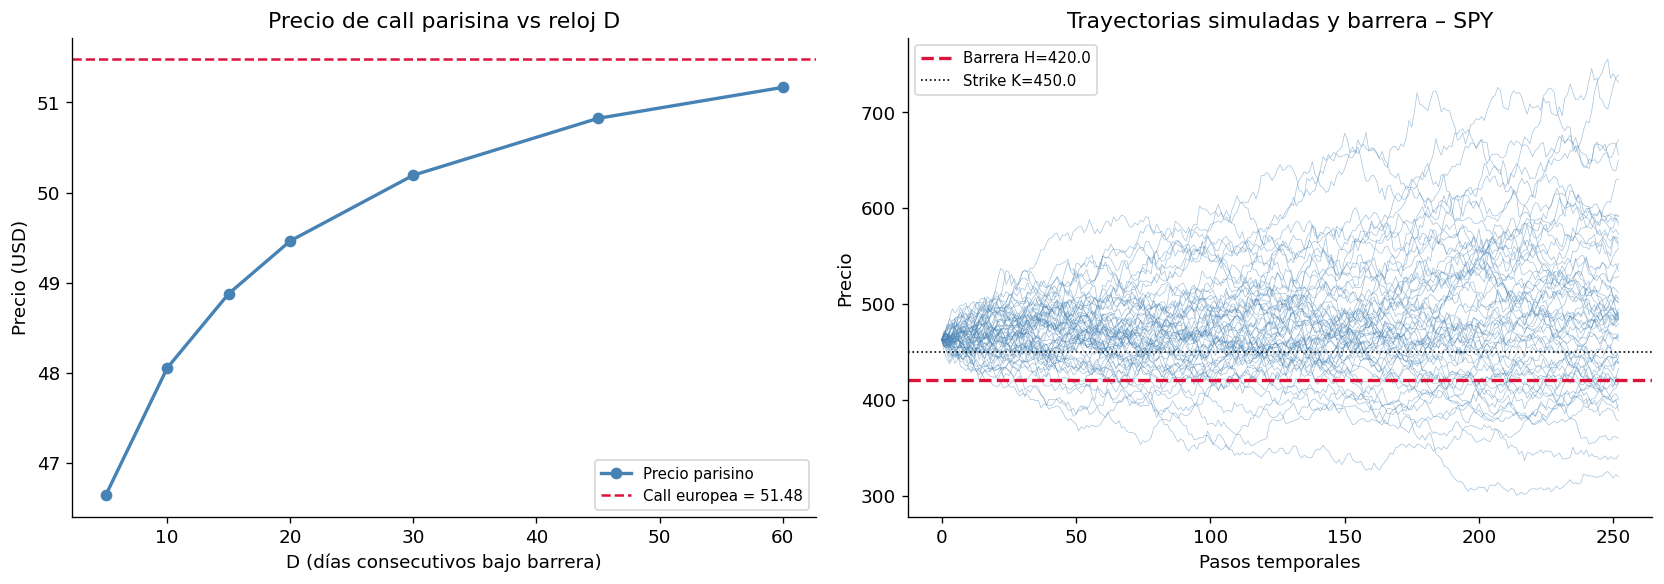


Tabla de precios parisinos:
 D (días)  Precio parisino
        5          46.6406
       10          48.0542
       15          48.8789
       20          49.4640
       30          50.1930
       45          50.8237
       60          51.1671

Interpretación: A mayor D, el precio parisino converge al precio
europeo estándar, pues se vuelve más difícil desactivar la opción.


In [17]:
print("\n" + "=" * 60)
print("  LABORATORIO 5: Opción Parisina – Reloj de Barrera")
print("=" * 60)

# ── Parámetros configurables ─────────────────────────────────
TICKER_L5  = "SPY"
INICIO_L5  = "2021-01-01"
FIN_L5     = "2024-01-01"
K_L5       = 450.0
T_L5       = 1.0
r_L5       = 0.05
H_L5       = 420.0        # Barrera (por debajo desactiva)
N_SIM_L5   = 80_000
N_PASOS_L5 = 252
RELOJES    = [5, 10, 15, 20, 30, 45, 60]   # duraciones D a evaluar
SEED_L5    = 2024

# ── Calibración ─────────────────────────────────────────────
datos_l5   = yf.download(TICKER_L5, start=INICIO_L5, end=FIN_L5,
                          auto_adjust=True, progress=False)["Close"].dropna()
log_ret_l5 = np.log(datos_l5 / datos_l5.shift(1)).dropna()
sigma_l5   = (log_ret_l5.std() * np.sqrt(252)).iloc[0]
S0_l5      = float(datos_l5.iloc[-1])

print(f"\nActivo: {TICKER_L5}  |  S0 = {S0_l5:.2f}  |  K = {K_L5}  |  H = {H_L5}")
print(f"σ = {sigma_l5:.4f}  |  r = {r_L5}  |  T = {T_L5}")
print(f"Simulaciones: {N_SIM_L5:,}  |  Relojes D: {RELOJES}")

# ── Simulación de trayectorias ────────────────────────────────
np.random.seed(SEED_L5)
dt_l5  = T_L5 / N_PASOS_L5
fact   = np.exp((r_L5 - 0.5 * sigma_l5**2) * dt_l5)
dif    = sigma_l5 * np.sqrt(dt_l5)

Z_l5   = np.random.standard_normal((N_PASOS_L5, N_SIM_L5))
S_l5   = np.zeros((N_PASOS_L5 + 1, N_SIM_L5))
S_l5[0] = S0_l5
for t in range(1, N_PASOS_L5 + 1):
    S_l5[t] = S_l5[t - 1] * fact * np.exp(dif * Z_l5[t - 1])

# Máscara de estar por debajo de la barrera (0/1)
bajo_barrera = (S_l5 < H_L5).astype(int)   # shape (N_PASOS+1, N_SIM)

# ── Función: precio parisino para un reloj D ─────────────────
def precio_parisino(D, S_mat, bajo_mat, K, r, T, n_pasos):
    """Call parisina: se desactiva si el activo permanece D días
    consecutivos por debajo de H."""
    n_sim = S_mat.shape[1]
    desact = np.zeros(n_sim, dtype=bool)
    contador = np.zeros(n_sim, dtype=int)

    for t in range(1, n_pasos + 1):
        abajo_t = bajo_mat[t].astype(bool)
        contador[abajo_t]  += 1
        contador[~abajo_t]  = 0
        desact |= (contador >= D)

    # Payoff call para paths no desactivados
    ST      = S_mat[-1]
    payoff  = np.where(desact, 0.0, np.maximum(ST - K, 0.0))
    precio  = np.exp(-r * T) * payoff.mean()
    return precio

# ── Barrido de relojes D ─────────────────────────────────────
resultados_l5 = []
for D in RELOJES:
    p = precio_parisino(D, S_l5, bajo_barrera, K_L5, r_L5, T_L5, N_PASOS_L5)
    resultados_l5.append({"D (días)": D, "Precio parisino": round(p, 4)})
    print(f"  D = {D:3d} días  →  Precio = {p:.4f}")

df_paris = pd.DataFrame(resultados_l5)

# Precio call europea sin barrera (referencia)
# The bs_precio function was defined in a previous cell (lab 3)
# but is not available in the current execution context (new cell).
# I will add the function definition here to ensure it's available.
def bs_precio(S, K, T, r, sigma, tipo="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if tipo == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
precio_ref = bs_precio(S0_l5, K_L5, T_L5, r_L5, sigma_l5, "call")
print(f"\n  Ref. Call Europea (sin barrera) = {precio_ref:.4f}")

# ── Gráficas ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: precio vs reloj D
ax = axes[0]
ax.plot(df_paris["D (días)"], df_paris["Precio parisino"],
        marker="o", color="steelblue", lw=2, label="Precio parisino")
ax.axhline(precio_ref, color="crimson", ls="--", lw=1.5,
           label=f"Call europea = {precio_ref:.2f}")
ax.set_title("Precio de call parisina vs reloj D")
ax.set_xlabel("D (días consecutivos bajo barrera)")
ax.set_ylabel("Precio (USD)")
ax.legend(fontsize=9)

# Derecha: trayectorias de muestra con barrera
ax2 = axes[1]
n_ej = 60
for i in range(n_ej):
    color = "tomato" if (bajo_barrera[1:, i].cumsum() == 0).all() else "steelblue"
    ax2.plot(S_l5[:, i], lw=0.4, alpha=0.5, color="steelblue")
ax2.axhline(H_L5, color="crimson", lw=2, ls="--", label=f"Barrera H={H_L5}")
ax2.axhline(K_L5, color="black",   lw=1, ls=":",  label=f"Strike K={K_L5}")
ax2.set_title(f"Trayectorias simuladas y barrera – {TICKER_L5}")
ax2.set_xlabel("Pasos temporales")
ax2.set_ylabel("Precio")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("lab5_parisina.png", bbox_inches="tight")
plt.show()

print("\nTabla de precios parisinos:")
print(df_paris.to_string(index=False))
print("\nInterpretación: A mayor D, el precio parisino converge al precio")
print("europeo estándar, pues se vuelve más difícil desactivar la opción.")